# 07｜MNIST 分類與錯誤分析

第三週主線；對應 `03_分類與模型評估.md` 的 MNIST、OOF 預測、PR／ROC、macro／weighted、錯誤切片、多標籤／多輸出。主線約 30 分鐘；最後兩節為選做。

## 來源與改編界線
- [ageron/handson-mlp / 03_classification.ipynb](https://github.com/ageron/handson-mlp/blob/47eba45aacc85feae51ba7db68dd1ca66cb25e0a/03_classification.ipynb)：儲存格 11–22 載入／固定 60k–10k；25–74 SGD／OOF／PR／ROC／森林；75–103 多類與錯誤分析；105–115 多標籤與去噪

**本課程修改／補充：** 固定 OpenML version 1 並使用已下載快取。fast 在原前 60k 中分層選 12k，再拆 9k fit／3k validation；最後 10k test 完整保留。先以 OOF AP 選二元模型，再用獨立 validation 選閾值，不在 test 調參。縮小 k-NN 多輸出示例，保留實際像素分類。多類別最終指標同時報 macro／weighted／micro F1，並驗證 micro F1＝accuracy。

來源固定至上述 commit；原檔保留於 `../upstream/`，逐檔 SHA-256 見 `../upstream/manifest.json`。Géron 程式依 Apache-2.0 改編，授權原文保留。儲存格索引從 0 起算。圖表與數值是本 Notebook 重跑結果，不能直接當成書中成效。

從第一格依序執行；各本可獨立重跑。Python 環境與資料準備見 [操作說明](../README.md)。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlcourse.common import ROOT, DATA, OUT, SEED, FAST, setup, savefig, report, data_path
setup()

{'profile': 'fast',
 'seed': 42,
 'data': '/Users/leonjye/Documents/MacProject/MLCourse2026/programs/data'}

## 1. 70,000 張、每張 28×28

先遵循教材前 60,000／後 10,000 的固定資料界線。fast 的 12,000 張來自前 60,000 分層抽樣，並非改用其他數字資料集。模型只在 fit 部分學習；validation 選閾值後不重新 fit，避免模型重訓改變分數尺度。

fit / validation / locked test: 9000 3000 10000


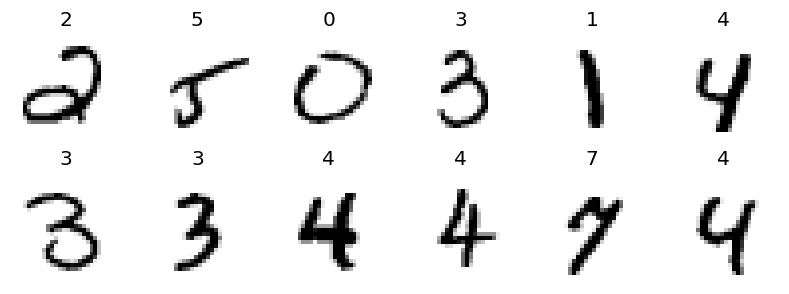

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.base import clone
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,
    classification_report,roc_auc_score,average_precision_score,precision_recall_curve,roc_curve,ConfusionMatrixDisplay)
with np.load(data_path('mnist_784_v1.npz')) as archive:
    images=archive['X'];labels=archive['y']
assert images.shape==(70000,784)
dev_ids=np.arange(60000)
if FAST:
    dev_ids,_=train_test_split(dev_ids,train_size=12000,stratify=labels[:60000],random_state=SEED)
fit_ids,val_ids=train_test_split(dev_ids,test_size=.25,stratify=labels[dev_ids],random_state=SEED)
test_ids=np.arange(60000,70000)
assert not set(fit_ids)&set(val_ids) and not set(dev_ids)&set(test_ids)
X_fit=images[fit_ids].astype(np.float32)/255
X_val=images[val_ids].astype(np.float32)/255
y_fit=labels[fit_ids];y_val=labels[val_ids]
y_fit5=y_fit==5;y_val5=y_val==5
print('fit / validation / locked test:',len(fit_ids),len(val_ids),len(test_ids))
fig,axes=plt.subplots(2,6,figsize=(9,3))
for ax,idx in zip(axes.ravel(),fit_ids[:12]):
    ax.imshow(images[idx].reshape(28,28),cmap='binary');ax.set_title(str(labels[idx]));ax.axis('off')
savefig('07_mnist_examples')

## 2. 「不是 5」就能有高 accuracy？

`cross_val_predict` 對每筆 fit 樣本只使用沒有看過該筆的模型產生 OOF 預測。三折以同一索引比較 SGD 與森林；縮放器放在 Pipeline，每折重新 fit。

OOF 用於開發集比較；選出最高 AP 的模型後，該 AP 也帶模型選擇偏差，不能充當最終 test 成效。

In [3]:
folds=list(StratifiedKFold(3,shuffle=True,random_state=SEED).split(X_fit,y_fit5))
binary_models={
    'SGD':make_pipeline(StandardScaler(with_mean=False),SGDClassifier(random_state=SEED,max_iter=1000,tol=1e-3)),
    'RandomForest':RandomForestClassifier(n_estimators=60,max_features='sqrt',n_jobs=2,random_state=SEED)
}
oof_scores={};rows=[]
dummy=cross_val_predict(DummyClassifier(strategy='most_frequent'),X_fit,y_fit5,cv=folds)
print('Always-majority baseline: accuracy=',accuracy_score(y_fit5,dummy),'recall=',recall_score(y_fit5,dummy))
for name,model in binary_models.items():
    method='decision_function' if name=='SGD' else 'predict_proba'
    score=cross_val_predict(model,X_fit,y_fit5,cv=folds,method=method,n_jobs=1)
    if method=='predict_proba': score=score[:,1]
    oof_scores[name]=score
    default_threshold=0 if name=='SGD' else .5
    pred=score>=default_threshold
    rows.append({'model':name,'OOF_accuracy':accuracy_score(y_fit5,pred),'OOF_precision':precision_score(y_fit5,pred),
                 'OOF_recall':recall_score(y_fit5,pred),'OOF_AP':average_precision_score(y_fit5,score),
                 'OOF_ROC_AUC':roc_auc_score(y_fit5,score)})
comparison=pd.DataFrame(rows).set_index('model')
comparison

Always-majority baseline: accuracy= 0.9096666666666666 recall= 0.0


,OOF_accuracy,OOF_precision,OOF_recall,OOF_AP,OOF_ROC_AUC
model,,,,,
SGD,0.952222,0.726627,0.755228,0.784180,0.947330
RandomForest,0.977000,0.988710,0.753998,0.961678,0.994041


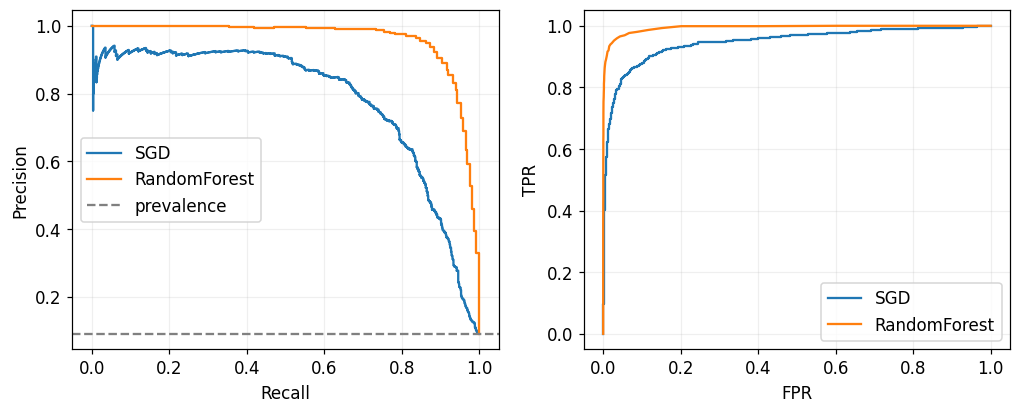

In [4]:
fig,axes=plt.subplots(1,2,figsize=(11,4))
for name,score in oof_scores.items():
    p,r,_=precision_recall_curve(y_fit5,score)
    fpr,tpr,_=roc_curve(y_fit5,score)
    axes[0].step(r,p,where='post',label=name);axes[1].plot(fpr,tpr,label=name)
axes[0].axhline(y_fit5.mean(),ls='--',color='grey',label='prevalence')
axes[0].set(xlabel='Recall',ylabel='Precision');axes[1].set(xlabel='FPR',ylabel='TPR')
for ax in axes:ax.legend()
savefig('07_binary_oof_curves')

## 3. 獨立 validation 選閾值

政策：在 validation 上 precision ≥ 0.90 的候選中，選 recall 最大的閾值。這是經驗估計；少量正例可使精確率不穩，不能宣稱部署保證。`precision_recall_curve` 最後一點沒有對應 threshold，須去除後才對齊。

In [5]:
selected_name=comparison.OOF_AP.idxmax()
selected=clone(binary_models[selected_name]).fit(X_fit,y_fit5)
def continuous_score(model,X):
    if hasattr(model,'decision_function'):return model.decision_function(X)
    return model.predict_proba(X)[:,list(model.classes_).index(True)]
val_score=continuous_score(selected,X_val)
p,r,thresholds=precision_recall_curve(y_val5,val_score)
feasible=np.flatnonzero(p[:-1]>=.90)
if len(feasible):
    best_index=feasible[np.argmax(r[:-1][feasible])]
    operating_threshold=float(thresholds[best_index])
else:
    operating_threshold=np.inf
val_pred=val_score>=operating_threshold
print('Selected by OOF AP:',selected_name,'threshold:',operating_threshold)
print('Validation precision / recall:',precision_score(y_val5,val_pred,zero_division=0),recall_score(y_val5,val_pred))
print('Validation TP / predicted positives:',int((val_pred&y_val5).sum()),int(val_pred.sum()))

Selected by OOF AP: RandomForest threshold: 0.31666666666666665
Validation precision / recall: 0.908745247148289 0.8819188191881919
Validation TP / predicted positives: 239 263


## 4. 多類別與錯誤分析：仍在開發集進行

固定 SGD 為多類別示範模型，比較固定像素除以 255 與額外 StandardScaler 的 CV accuracy。SGD 對多類別採 OvR。10×10 混淆矩陣列為真實、欄為預測；右圖依真實類別正規化後把對角設零，方便看錯誤流向，列加總因此不再是 1。

Without StandardScaler CV accuracy: 0.8736666666666667
With StandardScaler OOF accuracy: 0.8584444444444445
              precision    recall  f1-score   support

           0      0.928     0.931     0.930       889
           1      0.903     0.953     0.927      1011
           2      0.872     0.815     0.843       894
           3      0.841     0.817     0.829       919
           4      0.878     0.881     0.880       876
           5      0.729     0.813     0.769       813
           6      0.923     0.914     0.919       888
           7      0.876     0.881     0.879       940
           8      0.794     0.732     0.762       878
           9      0.829     0.828     0.829       892

    accuracy                          0.858      9000
   macro avg      0.857     0.857     0.856      9000
weighted avg      0.859     0.858     0.858      9000



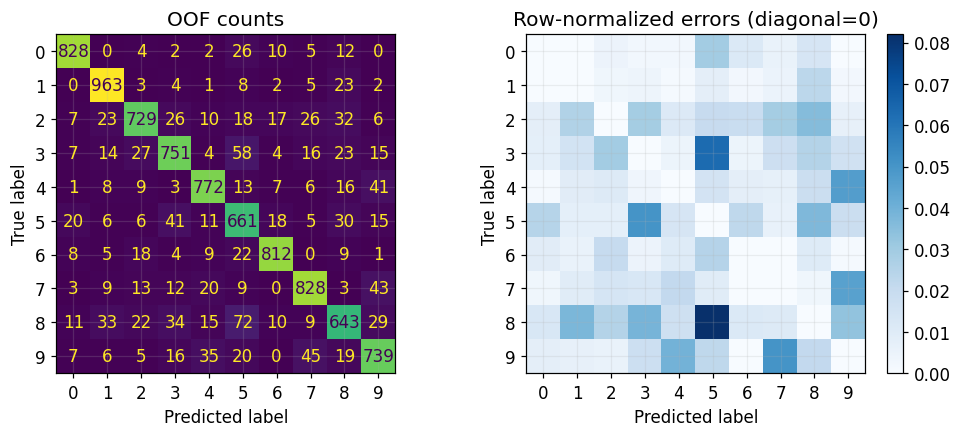

In [6]:
multi_folds=list(StratifiedKFold(3,shuffle=True,random_state=SEED).split(X_fit,y_fit))
plain=SGDClassifier(random_state=SEED,max_iter=1000,tol=1e-3)
plain_scores=cross_val_score(plain,X_fit,y_fit,cv=multi_folds,scoring='accuracy')
multi_model=make_pipeline(StandardScaler(with_mean=False),clone(plain))
multi_oof=cross_val_predict(multi_model,X_fit,y_fit,cv=multi_folds)
print('Without StandardScaler CV accuracy:',plain_scores.mean())
print('With StandardScaler OOF accuracy:',accuracy_score(y_fit,multi_oof))
print(classification_report(y_fit,multi_oof,zero_division=0,digits=3))
cm=confusion_matrix(y_fit,multi_oof,labels=np.arange(10))
normalized=cm/cm.sum(axis=1,keepdims=True)
np.fill_diagonal(normalized,0)
fig,axes=plt.subplots(1,2,figsize=(11,4))
ConfusionMatrixDisplay(cm,display_labels=np.arange(10)).plot(ax=axes[0],colorbar=False)
axes[0].set_title('OOF counts')
img=axes[1].imshow(normalized,cmap='Blues');fig.colorbar(img,ax=axes[1])
axes[1].set(xticks=range(10),yticks=range(10),xlabel='Predicted label',ylabel='True label',title='Row-normalized errors (diagonal=0)')
savefig('07_multiclass_confusion')

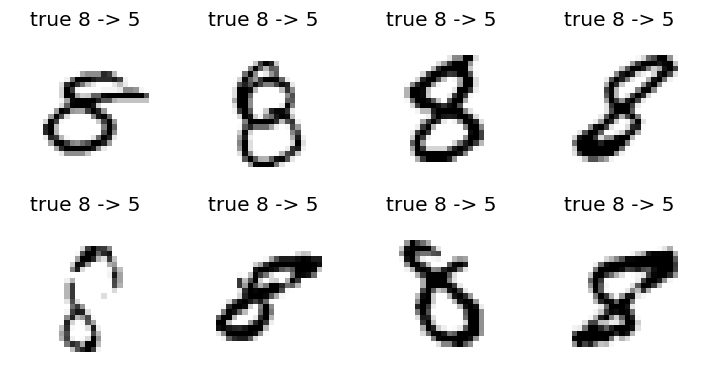

Most frequent OOF error pair: 8 -> 5 count: 72


In [7]:
offdiag=cm.copy();np.fill_diagonal(offdiag,0)
true_digit,pred_digit=np.unravel_index(offdiag.argmax(),offdiag.shape)
error_positions=np.flatnonzero((y_fit==true_digit)&(multi_oof==pred_digit))[:8]
fig,axes=plt.subplots(2,4,figsize=(8,4))
for ax in axes.ravel():ax.axis('off')
for ax,pos in zip(axes.ravel(),error_positions):
    ax.imshow(X_fit[pos].reshape(28,28),cmap='binary')
    ax.set_title(f'true {true_digit} -> {pred_digit}')
savefig('07_error_gallery')
print('Most frequent OOF error pair:',int(true_digit),'->',int(pred_digit),'count:',offdiag[true_digit,pred_digit])

`macro` 對每一類等權平均；`weighted` 按各類真實樣本數加權，常見類別可掩蓋少數類別弱點。下一格另報告 `micro` F1；單標籤、涵蓋全部類別時它等於 accuracy，並以 assert 驗證。錯誤圖只能提示待驗證的假設，如平移／筆畫相似；不能看完圖就斷言原因。

## 5. 兩個事先指定任務的最後 test

二元模型與閾值已固定；多類別模型也已固定。保留最後 10,000 張，這裡才讀取其標籤來評估。若再利用 test 調整設計，需要新的獨立評估。

In [8]:
X_test=images[test_ids].astype(np.float32)/255;y_test=labels[test_ids];y_test5=y_test==5
test_score=continuous_score(selected,X_test);test_pred=test_score>=operating_threshold
multi_model.fit(X_fit,y_fit);multi_test=multi_model.predict(X_test)
final={'profile':'fast' if FAST else 'full','fit_rows':len(X_fit),'validation_rows':len(X_val),'test_rows':len(X_test),
       'binary_model':selected_name,'threshold':operating_threshold,
       'binary_test_accuracy':accuracy_score(y_test5,test_pred),
       'binary_test_precision':precision_score(y_test5,test_pred,zero_division=0),
       'binary_test_recall':recall_score(y_test5,test_pred),
       'binary_test_AP':average_precision_score(y_test5,test_score),
       'binary_test_ROC_AUC':roc_auc_score(y_test5,test_score),
       'binary_test_CM':confusion_matrix(y_test5,test_pred,labels=[False,True]).tolist(),
       'multiclass_test_accuracy':accuracy_score(y_test,multi_test),
       'multiclass_test_macro_F1':f1_score(y_test,multi_test,average='macro'),
       'multiclass_test_weighted_F1':f1_score(y_test,multi_test,average='weighted'),
       'multiclass_test_micro_F1':f1_score(y_test,multi_test,average='micro')}
assert np.isclose(final['multiclass_test_micro_F1'],final['multiclass_test_accuracy'])
report('mnist_final',final)
pd.Series(final)

profile                                           fast
fit_rows                                          9000
validation_rows                                   3000
test_rows                                        10000
binary_model                              RandomForest
threshold                                     0.316667
binary_test_accuracy                            0.9866
binary_test_precision                         0.943794
binary_test_recall                            0.903587
binary_test_AP                                0.976717
binary_test_ROC_AUC                           0.996917
binary_test_CM                 [[9060, 48], [86, 806]]
multiclass_test_accuracy                        0.8638
multiclass_test_macro_F1                      0.862147
multiclass_test_weighted_F1                   0.864605
multiclass_test_micro_F1                        0.8638
dtype: object

## 6. 選做：多標籤與單一多類別的差異

每張數字可以同時具有 `large (≥7)` 與 `odd` 兩個標籤。使用前 2,000 筆 fit 資料訓練 k-NN，另在前 300 筆 validation 評估；此段為獨立示範，不報告 test 成效。

In [9]:
from sklearn.neighbors import KNeighborsClassifier
n_small=2000
Y_multi=np.c_[y_fit[:n_small]>=7,y_fit[:n_small]%2==1]
Y_val_multi=np.c_[y_val[:300]>=7,y_val[:300]%2==1]
knn_multi=KNeighborsClassifier(n_neighbors=3,n_jobs=2).fit(X_fit[:n_small],Y_multi)
label_pred=knn_multi.predict(X_val[:300])
print('Targets shape:',Y_multi.shape,'macro F1 across labels:',f1_score(Y_val_multi,label_pred,average='macro'))
pd.DataFrame({'digit':y_val[:8],'pred_large':label_pred[:8,0],'pred_odd':label_pred[:8,1]})

Targets shape: (2000, 2) macro F1 across labels: 0.9368946674203882


,digit,pred_large,pred_odd
0,4,False,False
1,8,True,False
2,3,False,True
3,4,False,False
4,3,False,True
5,9,True,True
6,9,True,True
7,8,True,False


## 7. 選做：784 輸出的像素去噪分類

沿用教材加 0–99 整數噪音，再以 `KNeighborsClassifier` 一次預測 784 個像素，每個像素是 0–255 類別之一。先轉 int16 再加噪音，避免 uint8 溢位；顯示時使用相同色階。這是多輸出分類示範，不是現代影像去噪模型，也不保證所有圖像的 MSE 都降低。

Validation pixel MSE, noisy / reconstructed: 3265.6484906462583 2986.6831845238094


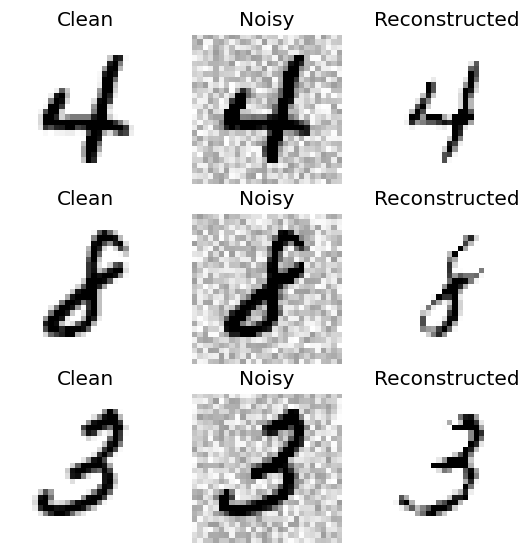

In [10]:
rng=np.random.default_rng(SEED)
clean_train=images[fit_ids[:n_small]]
clean_val=images[val_ids[:60]]
noisy_train=clean_train.astype(np.int16)+rng.integers(0,100,clean_train.shape,dtype=np.int16)
noisy_val=clean_val.astype(np.int16)+rng.integers(0,100,clean_val.shape,dtype=np.int16)
knn_pixels=KNeighborsClassifier(n_neighbors=3,n_jobs=2).fit(noisy_train,clean_train)
reconstructed=knn_pixels.predict(noisy_val)
assert reconstructed.shape==(60,784)
raw_mse=np.mean((noisy_val.astype(float)-clean_val)**2)
restored_mse=np.mean((reconstructed.astype(float)-clean_val)**2)
print('Validation pixel MSE, noisy / reconstructed:',raw_mse,restored_mse)
fig,axes=plt.subplots(3,3,figsize=(6,6))
for i in range(3):
    for j,(name,arr) in enumerate([('Clean',clean_val),('Noisy',noisy_val),('Reconstructed',reconstructed)]):
        axes[i,j].imshow(arr[i].reshape(28,28),cmap='binary',vmin=0,vmax=255)
        axes[i,j].set_title(name);axes[i,j].axis('off')
savefig('07_multioutput_denoising')
report('mnist_optional',{'multilabel_validation_macro_F1':f1_score(Y_val_multi,label_pred,average='macro'),
                         'noisy_validation_pixel_MSE':raw_mse,'reconstructed_validation_pixel_MSE':restored_mse})

## 練習與參考答案

- OOF 預測能否用來選模型又當作最終分數？**可以做開發比較，但選擇後需獨立 test 評估。**
- validation precision 達 90%，test 一定達到嗎？**不一定，有限樣本誤差與資料差異都會影響。**
- `[large, odd]` 可以同時為 True 嗎？**7 與 9 可以，故為多標籤。**
- 784 個像素輸出與 10 類數字標籤差在哪裡？**前者每個樣本有 784 個目標，後者每個樣本只有一個類別。**